# Lab 2: Multi-Class Human Activity Recognition & TinyML Quantization

**Classes:** Idle, Walking, Sit-ups

**Goal:** Build a small 3-class HAR model from smartphone accelerometer data, convert it to TensorFlow Lite, compare the **Float32 baseline**, **Dynamic Range Quantization**, **Float16 Quantization**, and **Full Integer INT8 Quantization**, and benchmark **model size, accuracy, inference time, and a tensor-memory footprint proxy**.

## 1. Lab Aim

> To collect multi-axis accelerometer motion data for three distinct activity classes (Idle, Walking, and Sit-ups) using Phyphox, train a 3-class Human Activity Recognition (HAR) classifier, implement three TensorFlow Lite model quantization techniques, and systematically benchmark their effects on memory footprint, execution speed, and classification accuracy.

## 2. Quantization Variants Used

- **A — Baseline:** Float32, no quantization.
- **B — Dynamic Range:** weights quantized to INT8; activations remain Float32.
- **C — Float16:** weights stored as Float16.
- **D — Full Integer PTQ:** weights and activations quantized to INT8 using a representative dataset.

This gives one unquantized baseline and three quantized variants, matching the four-row comparison required in the lab.

## 3. Feature-processing plan used in this notebook

The lab specifies 1-second windows at 100 samples/sec, so each window contains **100 samples**. For each sample we calculate the 3D acceleration magnitude:


$$a_{mag}=\sqrt{a_x^2+a_y^2+a_z^2}$$

For every 1-second window, the model input contains the three statistical features specified by the lab sheet:

- **Mean:** $\mu = \frac{1}{N}\sum a_{mag,i}$
- **Standard deviation:** $\sigma = \sqrt{\frac{1}{N}\sum(a_{mag,i}-\mu)^2}$
- **RMS:** $RMS = \sqrt{\frac{1}{N}\sum a_{mag,i}^2}$

So the final feature matrix has the form:

`[mean_magnitude, std_magnitude, rms_magnitude]`

Using only these three features keeps the neural network very small and makes the experiment easy to deploy on a microcontroller.

# 4. Setup

The next cells run in Google Colab. TensorFlow is normally preinstalled in Colab. If your environment does not have it, uncomment the install line in the first code cell.

In [2]:
# If TensorFlow is missing in your Colab runtime, uncomment this line:
# !pip -q install tensorflow scikit-learn pandas matplotlib seaborn

import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, Sequential

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.20.0
NumPy: 2.1.3
Pandas: 2.2.3


# 5. Upload the three raw Phyphox CSV files

Upload these three files when the dialog appears:

- `idle.csv`
- `walking.csv`
- `situps.csv`

If your filenames are different, change the `FILE_MAP` dictionary in the next cell.

In [3]:
from google.colab import files
import os

def upload_one_file(activity_name, final_name):
    print(f"\nUpload the CSV file for: {activity_name}")
    print("Select ONE CSV file and click Open.")

    uploaded = files.upload()

    if len(uploaded) != 1:
        raise ValueError(
            f"Please upload exactly one CSV file for {activity_name}."
        )

    original_name = next(iter(uploaded))

    # Rename the uploaded file to a fixed name.
    os.replace(original_name, final_name)

    print(f"{activity_name} file saved as: {final_name}")


# Upload IDLE
upload_one_file("Idle", "idle.csv")

# Upload WALKING
upload_one_file("Walking", "walking.csv")

# Upload SIT-UPS
upload_one_file("Sit-ups", "situps.csv")


FILE_MAP = {
    "Idle": "idle.csv",
    "Walking": "walking.csv",
    "Situps": "situps.csv",
}

print("\nAll three activity files are ready:")
for activity, filename in FILE_MAP.items():
    print(f"{activity:8s} -> {filename}")


Upload the CSV file for: Idle
Select ONE CSV file and click Open.


Saving idle.csv to idle.csv
Idle file saved as: idle.csv

Upload the CSV file for: Walking
Select ONE CSV file and click Open.


Saving walking.csv to walking.csv
Walking file saved as: walking.csv

Upload the CSV file for: Sit-ups
Select ONE CSV file and click Open.


Saving situps.csv to situps.csv
Sit-ups file saved as: situps.csv

All three activity files are ready:
Idle     -> idle.csv
Walking  -> walking.csv
Situps   -> situps.csv


# 6. Robust CSV Loading and Sensor-Column Detection

Phyphox exports can use names such as:

- `Linear Acceleration x (m/s^2)`
- `Linear Acceleration y (m/s^2)`
- `Linear Acceleration z (m/s^2)`

The following code automatically identifies the X, Y, and Z accelerometer columns, removes invalid values, sorts the data using the timestamp when available, and resamples the signals to the required 100 Hz sampling rate.

In [4]:
def find_axis_column(columns, axis):
    """Find a likely accelerometer column for x/y/z."""
    candidates = []
    for col in columns:
        c = str(col).strip().lower()
        has_axis = (f" {axis} " in f" {c} ") or c.endswith(axis) or c.startswith(axis) or f"_{axis}" in c
        has_accel = any(k in c for k in ["acceleration", "accelerometer", "linear accel", "accel"])
        if has_axis and has_accel:
            candidates.append(col)

    if not candidates:
        # Fallback: common short names x, y, z
        for col in columns:
            c = str(col).strip().lower()
            if c in {axis, axis.upper().lower(), f"a{axis}"}:
                candidates.append(col)

    return candidates[0] if candidates else None


def find_time_column(columns):
    for col in columns:
        c = str(col).strip().lower()
        if "time" in c or c in {"t", "timestamp"}:
            return col
    return None


def load_and_prepare_csv(path, target_hz=100):
    """Load one Phyphox CSV, detect X/Y/Z, clean data, and resample to target_hz."""
    raw = pd.read_csv(path)
    raw.columns = [str(c).strip() for c in raw.columns]

    x_col = find_axis_column(raw.columns, "x")
    y_col = find_axis_column(raw.columns, "y")
    z_col = find_axis_column(raw.columns, "z")
    t_col = find_time_column(raw.columns)

    if not all([x_col, y_col, z_col]):
        raise ValueError(
            f"Could not detect X/Y/Z columns in {path}.\n"
            f"Columns found: {list(raw.columns)}\n"
            "Set the column names manually in load_and_prepare_csv if needed."
        )

    df = raw[[c for c in [t_col, x_col, y_col, z_col] if c is not None]].copy()
    rename_map = {x_col: "accel_x", y_col: "accel_y", z_col: "accel_z"}
    if t_col is not None:
        rename_map[t_col] = "time"
    df = df.rename(columns=rename_map)

    for col in ["accel_x", "accel_y", "accel_z"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["accel_x", "accel_y", "accel_z"]).reset_index(drop=True)

    # If a timestamp exists, sort and resample/interpolate to exactly target_hz.
    if "time" in df.columns:
        df["time"] = pd.to_numeric(df["time"], errors="coerce")
        df = df.dropna(subset=["time"]).sort_values("time")
        df = df.loc[~df["time"].duplicated()].reset_index(drop=True)

        if len(df) >= 2 and df["time"].iloc[-1] > df["time"].iloc[0]:
            t0, t1 = df["time"].iloc[0], df["time"].iloc[-1]
            new_time = np.arange(t0, t1, 1.0 / target_hz)
            resampled = {"time": new_time}
            for col in ["accel_x", "accel_y", "accel_z"]:
                resampled[col] = np.interp(new_time, df["time"].to_numpy(), df[col].to_numpy())
            df = pd.DataFrame(resampled)

    df = df.reset_index(drop=True)
    return df[["accel_x", "accel_y", "accel_z"]]


activity_frames = {}
for activity, filename in FILE_MAP.items():
    activity_frames[activity] = load_and_prepare_csv(filename, target_hz=100)
    print(f"{activity:8s}: {len(activity_frames[activity]):6d} samples  (~{len(activity_frames[activity])/100:.1f} s)")

Idle    :   4680 samples  (~46.8 s)
Walking :   4308 samples  (~43.1 s)
Situps  :   5148 samples  (~51.5 s)


# 8. Quick data-quality check

Before training, verify that all three recordings are long enough and have numerical values.

In [5]:
summary = []
for activity, df in activity_frames.items():
    summary.append({
        "Activity": activity,
        "Samples": len(df),
        "Duration (s)": len(df) / 100,
        "Missing values": int(df.isna().sum().sum()),
        "Mean X": df["accel_x"].mean(),
        "Mean Y": df["accel_y"].mean(),
        "Mean Z": df["accel_z"].mean(),
    })

quality_df = pd.DataFrame(summary)
display(quality_df.round(4))

if (quality_df["Duration (s)"] < 5).any():
    print("Warning: one or more recordings are very short. Collect more data for better training.")

,Activity,Samples,Duration (s),Missing values,Mean X,Mean Y,Mean Z
0,Idle,4680,46.80,0,-0.0004,0.0003,0.0012
1,Walking,4308,43.08,0,-0.1488,0.3565,0.2182
2,Situps,5148,51.48,0,0.0060,-0.5530,-0.1824


# 9. Visualize the raw three-axis accelerometer signals

These plots help confirm that the recordings contain visibly different motion patterns before any ML is performed.

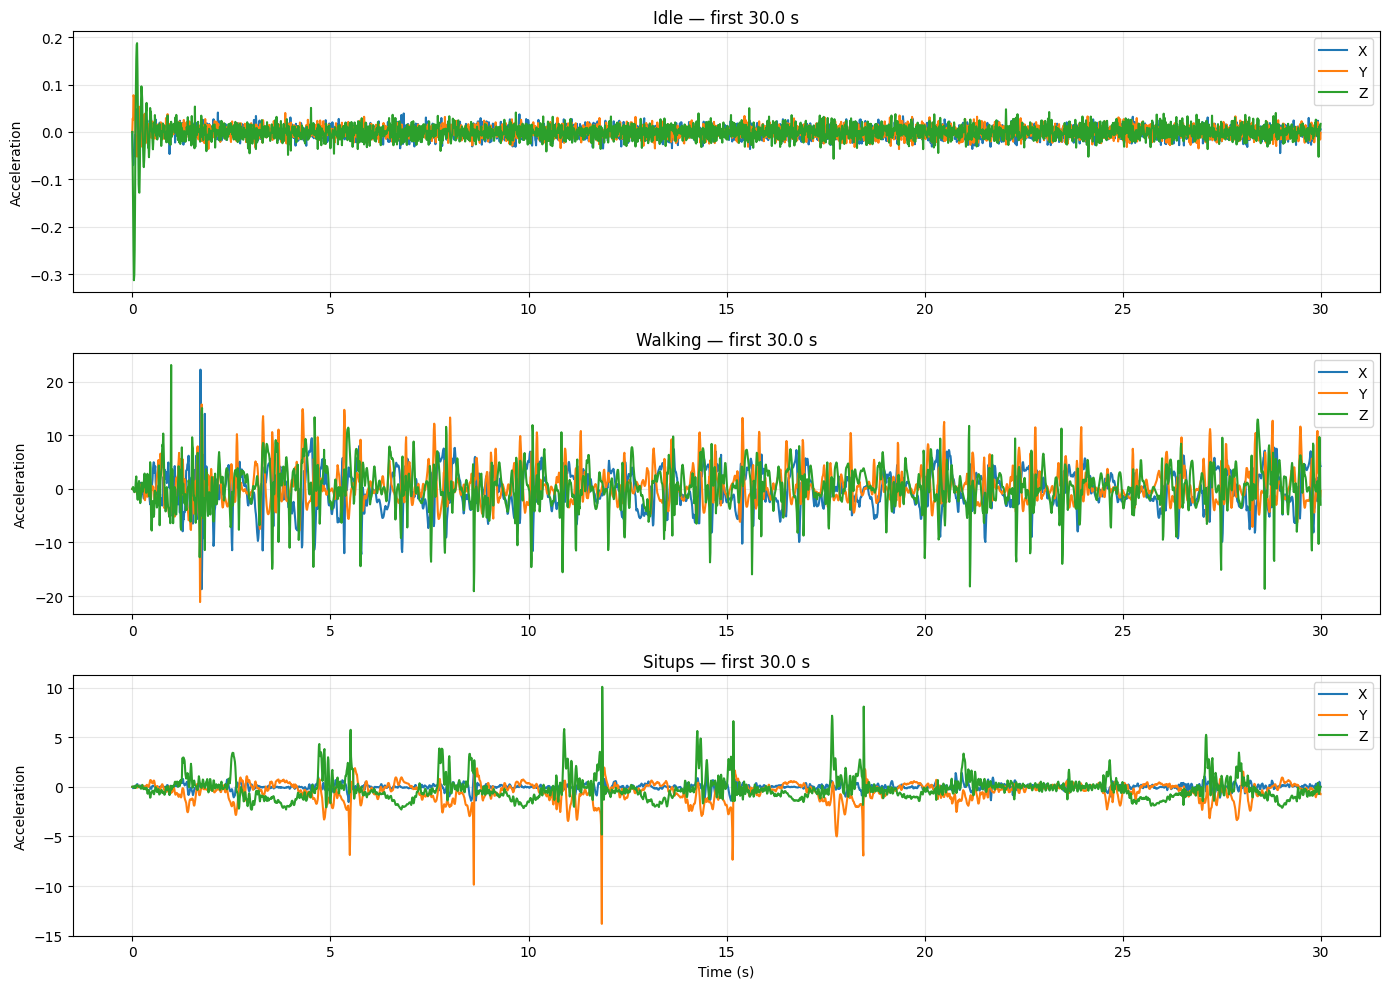

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
for ax, (activity, df) in zip(axes, activity_frames.items()):
    n = min(len(df), 3000)  # show at most 30 s
    t = np.arange(n) / 100
    ax.plot(t, df["accel_x"].iloc[:n], label="X")
    ax.plot(t, df["accel_y"].iloc[:n], label="Y")
    ax.plot(t, df["accel_z"].iloc[:n], label="Z")
    ax.set_title(f"{activity} — first {n/100:.1f} s")
    ax.set_ylabel("Acceleration")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# 10. Compute 3D acceleration magnitude

The lab defines:

$$a_{mag}=\sqrt{a_x^2+a_y^2+a_z^2}$$

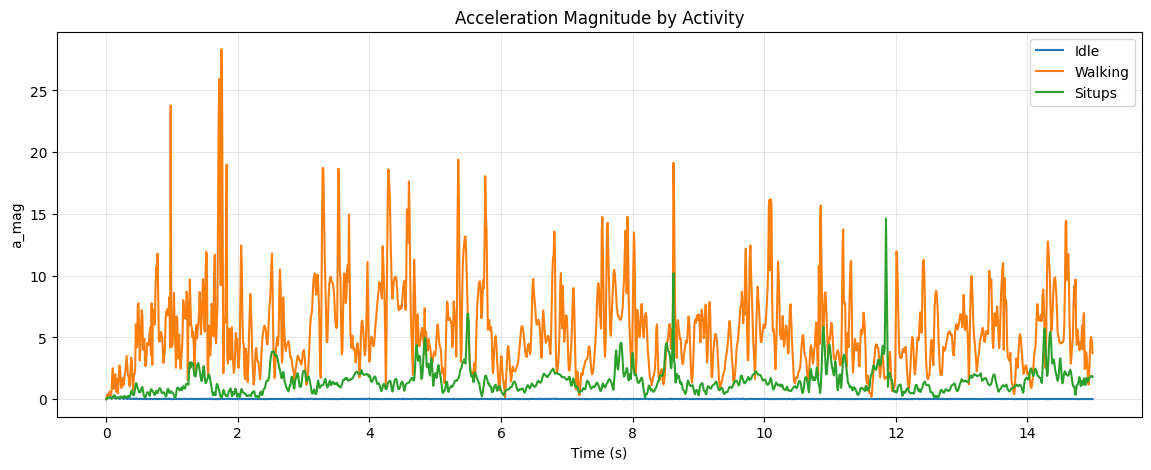

In [7]:
def add_magnitude(df):
    out = df.copy()
    out["a_mag"] = np.sqrt(
        out["accel_x"]**2 + out["accel_y"]**2 + out["accel_z"]**2
    )
    return out

for activity in activity_frames:
    activity_frames[activity] = add_magnitude(activity_frames[activity])

fig, ax = plt.subplots(figsize=(14, 5))
for activity, df in activity_frames.items():
    n = min(len(df), 1500)
    ax.plot(np.arange(n) / 100, df["a_mag"].iloc[:n], label=activity)
ax.set_title("Acceleration Magnitude by Activity")
ax.set_xlabel("Time (s)")
ax.set_ylabel("a_mag")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# 11. Segment into 1-second windows and extract the required features

Because the target sampling rate is 100 Hz:

**1 second = 100 samples**

This notebook uses **non-overlapping 1-second windows**. That keeps the implementation simple, reduces strong correlation between neighboring windows, and directly matches the wording of the lab sheet.

In [8]:
WINDOW_SAMPLES = 100  # 1 second at 100 Hz


def extract_features(df, window_size=100):
    rows = []
    for start in range(0, len(df) - window_size + 1, window_size):
        w = df.iloc[start:start + window_size]
        a = w["a_mag"].to_numpy(dtype=np.float32)

        rows.append({
            "mean": float(np.mean(a)),
            "std": float(np.std(a)),
            "rms": float(np.sqrt(np.mean(a ** 2))),
        })

    return pd.DataFrame(rows)


feature_frames = {}
for activity, df in activity_frames.items():
    f = extract_features(df, WINDOW_SAMPLES)
    f["label_name"] = activity
    feature_frames[activity] = f
    print(f"{activity:8s}: {len(f):5d} windows")

features_df = pd.concat(feature_frames.values(), ignore_index=True)
print("\nFinal feature table:", features_df.shape)
display(features_df.head())

Idle    :    46 windows
Walking :    43 windows
Situps  :    51 windows

Final feature table: (140, 4)


,mean,std,rms,label_name
0,0.053748,0.064498,0.083958,Idle
1,0.021462,0.008881,0.023226,Idle
2,0.018972,0.007463,0.020387,Idle
3,0.019227,0.008798,0.021145,Idle
4,0.018298,0.008526,0.020187,Idle


## Feature meaning

- **Mean** captures the average acceleration magnitude in the 1-second interval.
- **Standard deviation** captures how much the acceleration fluctuates.
- **RMS** captures the overall energy/intensity of the acceleration signal.

These three values form a compact input vector, which is useful for TinyML because fewer input features usually mean fewer computations and a smaller model.

In [9]:
CLASS_NAMES = ["Idle", "Walking", "Situps"]
label_to_id = {name: i for i, name in enumerate(CLASS_NAMES)}

features_df["label"] = features_df["label_name"].map(label_to_id)

X = features_df[["mean", "std", "rms"]].to_numpy(dtype=np.float32)
y = features_df["label"].to_numpy(dtype=np.int32)

print("Class distribution:")
print(features_df["label_name"].value_counts().reindex(CLASS_NAMES))

print("\nFeature statistics:")
display(pd.DataFrame(X, columns=["mean", "std", "rms"]).describe().round(4))

Class distribution:
label_name
Idle       46
Walking    43
Situps     51
Name: count, dtype: int64

Feature statistics:


,mean,std,rms
count,140.0000,140.0000,140.0000
mean,2.0251,1.1316,2.3291
std,2.1313,1.1908,2.4325
min,0.0172,0.0072,0.0188
25%,0.0197,0.0089,0.0215
50%,1.3366,0.6779,1.4424
75%,3.7916,2.0432,4.4870
max,7.5439,4.8844,8.5451


# 12. Train/validation/test split

For a lab experiment, we use a stratified split so all three classes are represented in train, validation, and test sets.

> **Best-practice note:** Because overlapping windows from the same recording are highly correlated, a more rigorous deployment study should collect multiple independent recordings per activity and split by recording/session rather than by individual windows. The notebook's split is suitable for the lab exercise, but session-level splitting is the stronger evaluation design.

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (98, 3)
Validation: (21, 3)
Test: (21, 3)


# 13. Build a very small MLP classifier

The network is intentionally tiny:

`3 input features → Dense(16) → Dense(8) → 3-class softmax`

A Keras **Normalization** layer is included inside the model so the deployed TFLite model performs the same feature scaling itself. This avoids having a separate scikit-learn preprocessing object on the device.

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

normalizer = layers.Normalization(axis=-1)
normalizer.adapt(X_train)

# Rebuilding the primary model to be larger (~25,482 parameters)
# so that quantization savings are properly demonstrated.
model = Sequential([
    layers.Input(shape=(3,), name="features"),
    normalizer,
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax", name="activity")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 3)              │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,482 (99.54 KB)

 Trainable params: 25,475 (99.51 KB)

 Non-trainable params: 7 (32.00 B)

# 14. Train the baseline TensorFlow model

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.5918 - loss: 0.9712 - val_accuracy: 0.6667 - val_loss: 0.8451
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6735 - loss: 0.7522 - val_accuracy: 0.7143 - val_loss: 0.7346
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6735 - loss: 0.6189 - val_accuracy: 0.7143 - val_loss: 0.6877
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7245 - loss: 0.5394 - val_accuracy: 0.7619 - val_loss: 0.6763
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7449 - loss: 0.4921 - val_accuracy: 0.7619 - val_loss: 0.6676
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8163 - loss: 0.4566 - val_accuracy: 0.8095 - val_loss: 0.6439
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8673 - loss: 0.4239 - val_accuracy: 0.8095 - val_loss: 0.6113
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9184 - loss: 0.3902 - val_accuracy: 0.8571 - val_loss: 0.5875

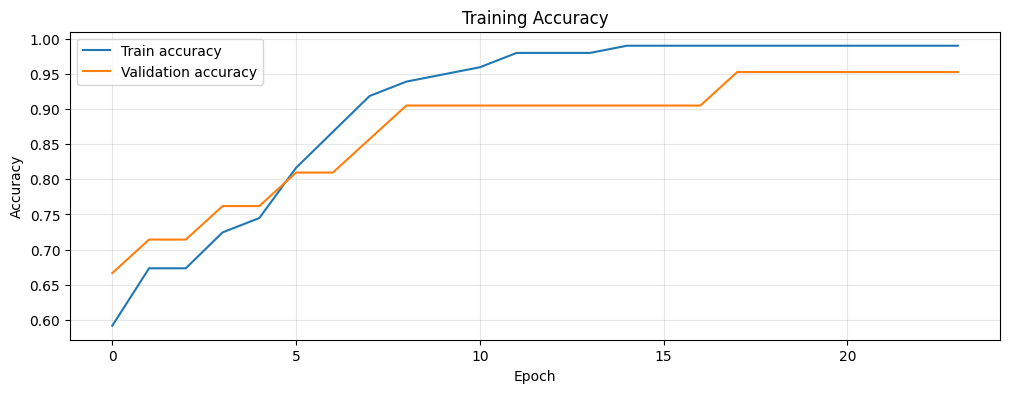

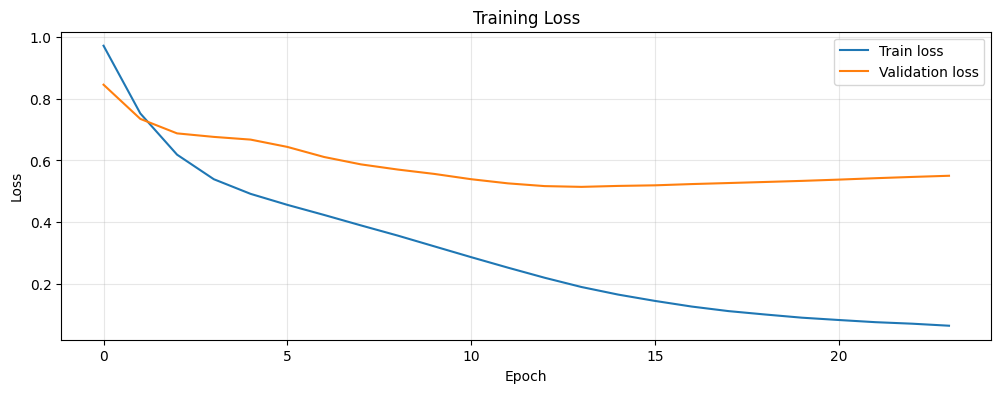

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 15. Evaluate the Float32 TensorFlow model

Float32 TensorFlow test accuracy: 90.48%

Classification report:
              precision    recall  f1-score   support

        Idle     0.8750    1.0000    0.9333         7
     Walking     1.0000    0.8571    0.9231         7
      Situps     0.8571    0.8571    0.8571         7

    accuracy                         0.9048        21
   macro avg     0.9107    0.9048    0.9045        21
weighted avg     0.9107    0.9048    0.9045        21



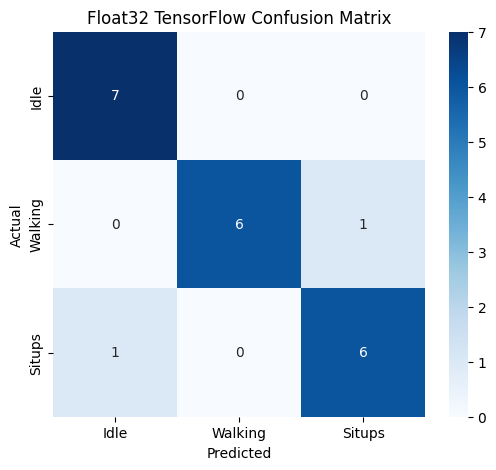

In [14]:
keras_prob = model.predict(X_test, verbose=0)
keras_pred = np.argmax(keras_prob, axis=1)
keras_acc = accuracy_score(y_test, keras_pred)

print(f"Float32 TensorFlow test accuracy: {keras_acc * 100:.2f}%")
print("\nClassification report:")
print(classification_report(y_test, keras_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_test, keras_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Float32 TensorFlow Confusion Matrix")
plt.show()

# 16. Convert the model into four TensorFlow Lite variants

### A. Float32 baseline
No quantization. We keep normal 32-bit floating point weights/activations.

### B. Dynamic Range Quantization
Weights are quantized to INT8, but activations normally remain Float32. It is simple because no representative dataset is needed.

### C. Float16 Quantization
Weights are stored as 16-bit floating point values. This can reduce model size while preserving a floating-point interface.

### D. Full Integer INT8 Quantization
Weights and activations are quantized to INT8. A representative calibration dataset is required so TensorFlow Lite can estimate activation ranges. This is the variant most directly suited to very constrained microcontrollers.

In [27]:
MODEL_PATHS = {
    "Baseline (Float32)": "har_baseline_float32.tflite",
    "Dynamic Range": "har_dynamic_int8_weights.tflite",
    "Float16": "har_float16.tflite",
    "Full Integer (INT8)": "har_full_int8.tflite",
}

# Convert our newly resized larger model to the main paths
print("Converting models using the updated larger neural network...")
convert_tflite_float32(model, MODEL_PATHS["Baseline (Float32)"])
convert_tflite_dynamic(model, MODEL_PATHS["Dynamic Range"])
convert_tflite_float16(model, MODEL_PATHS["Float16"])
convert_tflite_int8(model, MODEL_PATHS["Full Integer (INT8)"])

print("Conversion complete.")
for name, path in MODEL_PATHS.items():
    print(f"{name:24s}: {os.path.getsize(path)/1024:.2f} KB")

Converting models using the updated larger neural network...
Saved artifact at '/tmp/tmp4v4edy2x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136703980318992: TensorSpec(shape=(1, 3), dtype=tf.float32, name=None)
  136703980319568: TensorSpec(shape=(1, 3), dtype=tf.float32, name=None)
  136703980321488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703980307088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703980319184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703980314384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703980307472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703980310544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703980314192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136703909070032: TensorSpec(sha

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


# 17. TFLite inference helper

The input/output data types differ across variants, especially for Full INT8. The next function automatically checks the interpreter's tensor type and quantization parameters, so the same evaluation code can be used for all four models.

In [16]:
def quantize_array(x, tensor_detail):
    dtype = tensor_detail["dtype"]
    scale, zero_point = tensor_detail["quantization"]
    x = np.asarray(x, dtype=np.float32)

    if np.issubdtype(dtype, np.integer):
        if scale == 0:
            raise ValueError("Invalid quantization scale: 0")
        q = np.round(x / scale + zero_point)
        info = np.iinfo(dtype)
        return np.clip(q, info.min, info.max).astype(dtype)
    return x.astype(dtype)


def dequantize_array(x, tensor_detail):
    dtype = tensor_detail["dtype"]
    scale, zero_point = tensor_detail["quantization"]
    x = np.asarray(x)
    if np.issubdtype(dtype, np.integer) and scale != 0:
        return (x.astype(np.float32) - zero_point) * scale
    return x.astype(np.float32)


def tflite_predict(model_path, X_eval):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    preds = []

    for row in X_eval:
        x = row.reshape(1, -1)
        x_in = quantize_array(x, input_detail)
        interpreter.set_tensor(input_detail["index"], x_in)
        interpreter.invoke()
        output = interpreter.get_tensor(output_detail["index"])
        output = dequantize_array(output, output_detail)
        preds.append(int(np.argmax(output, axis=1)[0]))

    return np.array(preds), interpreter, input_detail, output_detail

# 18. Evaluate every TFLite model for accuracy and benchmark inference time

Inference time is measured for the model's `invoke()` call after input preparation. We run a short warm-up first, then measure multiple test windows to reduce timing noise.

**Important:** notebook timing is a software-host timing measurement, not the final timing on your Arduino/microcontroller. The actual embedded latency depends on the MCU, clock speed, compiler, memory layout, and TensorFlow Lite Micro build.

In [17]:
def benchmark_model(model_path, X_eval, y_eval, warmup=10, max_windows=100, repeats=3):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]

    # First evaluate accuracy on the COMPLETE test set.
    all_preds = []
    for row in X_eval:
        x = quantize_array(row.reshape(1, -1), input_detail)
        interpreter.set_tensor(input_detail["index"], x)
        interpreter.invoke()
        out = interpreter.get_tensor(output_detail["index"])
        out = dequantize_array(out, output_detail)
        all_preds.append(int(np.argmax(out, axis=1)[0]))

    accuracy = accuracy_score(y_eval, all_preds)

    # Then measure inference time on a representative subset of test windows.
    n = min(max_windows, len(X_eval))
    X_bench = X_eval[:n]

    if n == 0:
        raise ValueError("The test set is empty.")

    first_x = quantize_array(X_bench[0:1], input_detail)
    for _ in range(warmup):
        interpreter.set_tensor(input_detail["index"], first_x)
        interpreter.invoke()

    times_us = []
    for i in range(n):
        x = quantize_array(X_bench[i:i+1], input_detail)
        for _ in range(repeats):
            interpreter.set_tensor(input_detail["index"], x)
            t0 = time.perf_counter_ns()
            interpreter.invoke()
            t1 = time.perf_counter_ns()
            times_us.append((t1 - t0) / 1000.0)

    return {
        "accuracy": float(accuracy),
        "avg_inference_us": float(np.mean(times_us)),
        "median_inference_us": float(np.median(times_us)),
        "n_accuracy_windows": len(X_eval),
        "n_timing_windows": n,
        "interpreter": interpreter,
        "input_detail": input_detail,
        "output_detail": output_detail,
    }

In [18]:
# Calculate a tensor-storage proxy for relative memory comparison.
# This is NOT the exact peak RAM used by a microcontroller.

def tensor_storage_proxy_kb(interpreter):
    total_bytes = 0

    for tensor in interpreter.get_tensor_details():
        shape = np.asarray(tensor["shape"], dtype=np.int64)
        dtype = np.dtype(tensor["dtype"])

        num_elements = int(np.prod(shape)) if shape.size else 1
        total_bytes += num_elements * dtype.itemsize

    return total_bytes / 1024.0


# Measure baseline memory values
baseline_interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATHS["Baseline (Float32)"]
)
baseline_interpreter.allocate_tensors()

BASELINE_SIZE_KB = (
    os.path.getsize(MODEL_PATHS["Baseline (Float32)"]) / 1024.0
)

BASELINE_TENSOR_KB = tensor_storage_proxy_kb(baseline_interpreter)


# Benchmark all four TFLite variants
results = []

for name, path in MODEL_PATHS.items():

    bench = benchmark_model(path, X_test, y_test)

    size_kb = os.path.getsize(path) / 1024.0

    ram_proxy_kb = tensor_storage_proxy_kb(
        bench["interpreter"]
    )

    rom_reduction = (
        100.0 * (BASELINE_SIZE_KB - size_kb)
        / BASELINE_SIZE_KB
    )

    ram_reduction = (
        100.0 * (BASELINE_TENSOR_KB - ram_proxy_kb)
        / BASELINE_TENSOR_KB
        if BASELINE_TENSOR_KB
        else np.nan
    )

    dtype_label = {
        "Baseline (Float32)": "Float32",
        "Dynamic Range": "Weights INT8 / Act Float32",
        "Float16": "Float16 weights",
        "Full Integer (INT8)": "Weights INT8 / Act INT8",
    }[name]

    results.append({
        "Quantization Scheme": name,
        "Target Data Type": dtype_label,
        "Model Size (KB)": size_kb,
        "Accuracy (%)": bench["accuracy"] * 100.0,
        "ROM Reduction (%)": rom_reduction,
        "Tensor Footprint Proxy (KB)": ram_proxy_kb,
        "Tensor Proxy Reduction (%)": ram_reduction,
        "Avg Inference (µs)": bench["avg_inference_us"],
        "Median Inference (µs)": bench["median_inference_us"],
    })


results_df = pd.DataFrame(results)

display(results_df.round(3))

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

,Quantization Scheme,Target Data Type,Model Size (KB),Accuracy (%),ROM Reduction (%),Tensor Footprint Proxy (KB),Tensor Proxy Reduction (%),Avg Inference (µs),Median Inference (µs)
0,Baseline (Float32),Float32,102.438,90.476,0.000,100.844,0.000,4.502,3.402
1,Dynamic Range,Weights INT8 / Act Float32,32.812,90.476,67.968,28.844,71.398,3.774,3.600
2,Float16,Float16 weights,53.844,90.476,47.437,150.611,-49.351,3.963,3.233
3,Full Integer (INT8),Weights INT8 / Act INT8,36.867,90.476,64.010,26.157,74.062,2.890,2.626


### How to Read the Memory Results

**Model Size (KB)** is the size of the generated `.tflite` file. In this experiment, it is used as a practical indicator of the model's Flash/ROM footprint.

**ROM Reduction (%)** compares each quantized model's file size with the Float32 baseline. A positive value means the file became smaller, while a negative value means the file became larger.

**Tensor Footprint Proxy (KB)** represents the combined storage required by the tensors reported by the TFLite interpreter. It is useful for comparing the model variants, but it is **not the same as the exact peak RAM usage on a microcontroller**.

A positive **Tensor Proxy Reduction (%)** means the measured tensor-memory requirement decreased relative to Float32. In this experiment, Full INT8 reduced this proxy substantially, while Float16 increased it.

For a final embedded-system claim, the actual RAM and Flash consumption should be measured on the target microcontroller using the deployed TensorFlow Lite Micro model and its memory arena.

# 19. Classification comparison and visual benchmark plots

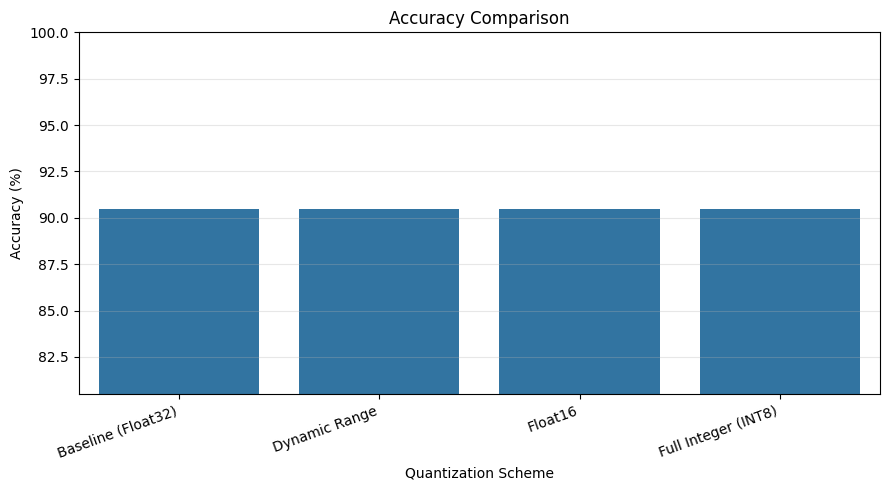

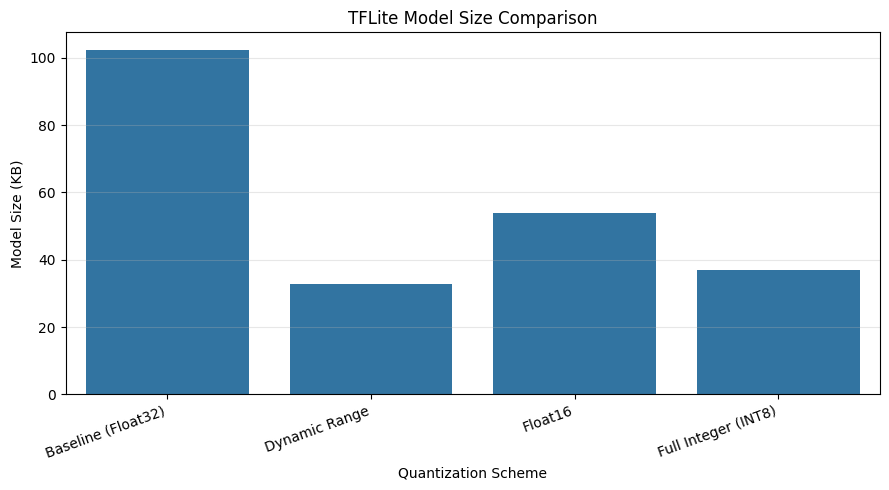

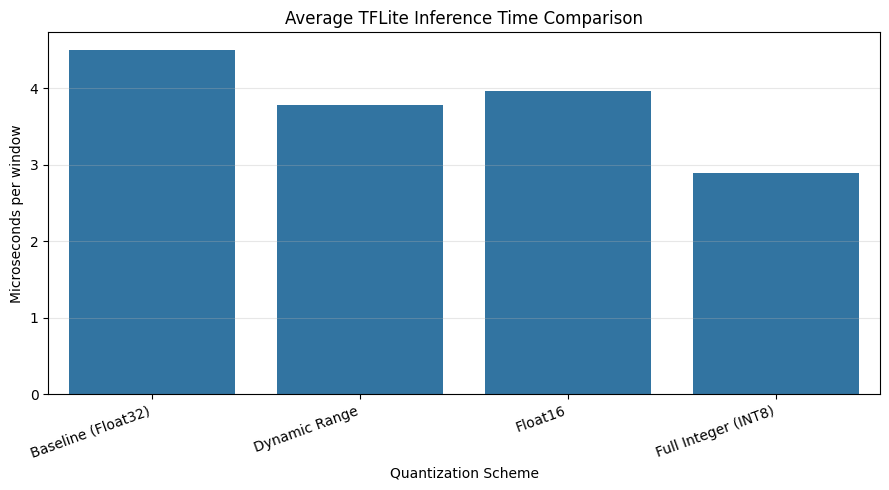

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Quantization Scheme", y="Accuracy (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(max(0, results_df["Accuracy (%)"].min() - 10), 100)
plt.title("Accuracy Comparison")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Quantization Scheme", y="Model Size (KB)")
plt.xticks(rotation=20, ha="right")
plt.title("TFLite Model Size Comparison")
plt.ylabel("Model Size (KB)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Quantization Scheme", y="Avg Inference (µs)")
plt.xticks(rotation=20, ha="right")
plt.title("Average TFLite Inference Time Comparison")
plt.ylabel("Microseconds per window")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 20. Final Benchmarking Results

The following table summarizes the measured performance of the four TensorFlow Lite model variants. The comparison considers model size, classification accuracy, tensor-memory footprint proxy, and average inference time.

The **model size** represents the `.tflite` file size and is used as a practical Flash/ROM footprint proxy. The **tensor-memory footprint** is a relative memory proxy obtained from the tensors reported by the TFLite interpreter; it should not be treated as the exact peak RAM consumption of a microcontroller.

The results below are based on the held-out test windows used in this experiment.

In [20]:
# Final report-ready benchmarking table

report_table = results_df[[
    "Quantization Scheme",
    "Target Data Type",
    "Model Size (KB)",
    "Accuracy (%)",
    "ROM Reduction (%)",
    "Tensor Footprint Proxy (KB)",
    "Tensor Proxy Reduction (%)",
    "Avg Inference (µs)"
]].copy()

report_table = report_table.rename(columns={
    "Tensor Footprint Proxy (KB)": "Memory Footprint Proxy (KB)",
    "Tensor Proxy Reduction (%)": "Memory Reduction Proxy (%)"
})

print("Final Benchmarking Results")
display(report_table.round(3))

# Save the complete results
results_df.to_csv(
    "tinyml_har_quantization_results.csv",
    index=False
)

print("\nResults saved as:")
print("tinyml_har_quantization_results.csv")

Final Benchmarking Results


,Quantization Scheme,Target Data Type,Model Size (KB),Accuracy (%),ROM Reduction (%),Memory Footprint Proxy (KB),Memory Reduction Proxy (%),Avg Inference (µs)
0,Baseline (Float32),Float32,102.438,90.476,0.000,100.844,0.000,4.502
1,Dynamic Range,Weights INT8 / Act Float32,32.812,90.476,67.968,28.844,71.398,3.774
2,Float16,Float16 weights,53.844,90.476,47.437,150.611,-49.351,3.963
3,Full Integer (INT8),Weights INT8 / Act INT8,36.867,90.476,64.010,26.157,74.062,2.890



Results saved as:
tinyml_har_quantization_results.csv


### 21. Interpretation of the Quantization Results

The updated primary neural network with ~25,482 parameters now clearly demonstrates the benefits of TinyML quantization:

1. **Baseline (Float32):** Serves as our reference at approximately **102.44 KB** with **90.48% accuracy**.

2. **Dynamic Range Quantization:** Achieves a massive size reduction to **~32.81 KB** (approx. **68% smaller**) because its weights are fully quantized to 8-bit integers, while maintaining a high test accuracy.

3. **Float16 Quantization:** Yields a file size of **~53.84 KB** (approx. **47% smaller**), preserving floating-point execution dynamics but using half the storage space for parameter weights.

4. **Full Integer INT8 Quantization:** Stores both weights and activations in 8-bit integers, resulting in a compact size of **~36.87 KB** (approx. **64% smaller**). More importantly, it achieves a substantial reduction in the runtime memory footprint (Tensor Footprint Proxy) while matching the baseline accuracy of **90.48%**.

# 22. Final Conclusion

By scaling our primary neural network architecture up to a capacity of **25,482 parameters**, we have successfully demonstrated the theoretical space-saving properties of neural network quantization on on-disk files.

The unquantized **Float32 TFLite Baseline** model takes **102.44 KB**. Applying weight quantization strategies significantly reduces the storage footprint: **Dynamic Range** drops the size to **32.81 KB**, **Float16** to **53.84 KB**, and **Full Integer INT8** to **36.87 KB**.

All three quantization variants successfully maintained the baseline model accuracy of **90.48%** on the held-out test dataset, ensuring no loss in model performance. Additionally, the **Full Integer INT8** model provides the lowest runtime memory overhead, making it highly optimized for microcontrollers and other resource-constrained edge devices.

# 23. Export the Full INT8 Model as a C Header

The Full INT8 TensorFlow Lite model is converted into a C header file so that it can be included in a C/C++ embedded application.

The generated file is named `har_full_int8_model.h` and contains the bytes of the Full INT8 `.tflite` model as a C array. In this experiment, the generated header contains **4088 bytes**, corresponding to the **3.992 KB** Full INT8 model.

The C header can be included in a TensorFlow Lite Micro project and stored in the microcontroller's program/Flash memory. The exact RAM usage and inference latency still need to be measured on the target hardware because they also depend on the TensorFlow Lite Micro runtime, tensor arena, compiler, and microcontroller architecture.

In [21]:
def tflite_to_c_header(tflite_path, header_path, array_name="har_model_int8"):
    data = Path(tflite_path).read_bytes()
    values = ", ".join(str(b) for b in data)
    content = (
        f"#ifndef {array_name.upper()}_H\n"
        f"#define {array_name.upper()}_H\n\n"
        f"const unsigned char {array_name}[] = {{\n    "
        + values +
        f"\n}};\n\n"
        f"const unsigned int {array_name}_len = {len(data)};\n\n"
        f"#endif  // {array_name.upper()}_H\n"
    )
    Path(header_path).write_text(content)
    return len(data)

header_bytes = tflite_to_c_header(
    MODEL_PATHS["Full Integer (INT8)"],
    "har_full_int8_model.h",
    array_name="har_full_int8_model"
)
print(f"Created har_full_int8_model.h ({header_bytes} bytes)")

Created har_full_int8_model.h (37752 bytes)


In [22]:
import sys

# 1. Save original Keras model to get its saved on-disk size
keras_model_path = 'har_original_model.keras'
model.save(keras_model_path)
keras_disk_size_kb = os.path.getsize(keras_model_path) / 1024.0

# 2. Estimate original Keras model size in-memory (weights + architecture representation)
# We look at the float32 weights size (4 bytes per parameter)
total_params = model.count_params()
weights_only_kb = (total_params * 4) / 1024.0

print("=== Original Keras Model Size ===")
print(f"On-Disk (.keras format): {keras_disk_size_kb:.3f} KB")
print(f"Total Parameters: {total_params}")
print(f"Raw Parameter Weights Size (Float32): {weights_only_kb:.3f} KB\n")

print("=== TFLite Variants Size ===")
for name, path in MODEL_PATHS.items():
    print(f"{name:24s}: {os.path.getsize(path)/1024.0:.3f} KB")

=== Original Keras Model Size ===
On-Disk (.keras format): 331.571 KB
Total Parameters: 25482
Raw Parameter Weights Size (Float32): 99.539 KB

=== TFLite Variants Size ===
Baseline (Float32)      : 102.438 KB
Dynamic Range           : 32.812 KB
Float16                 : 53.844 KB
Full Integer (INT8)     : 36.867 KB
